In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/processed/heart_processed.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
X = df.drop("target", axis=1)

y = df["target"]

In [4]:
X = pd.get_dummies(
    X,
    columns=["cp","restecg","slope","thal"],
    drop_first=True,
    dtype=int
)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [7]:
log_model = LogisticRegression(random_state=42)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [8]:
y_pred = log_model.predict(X_test_scaled)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.819672131147541


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.82      0.83        33
           1       0.79      0.82      0.81        28

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61



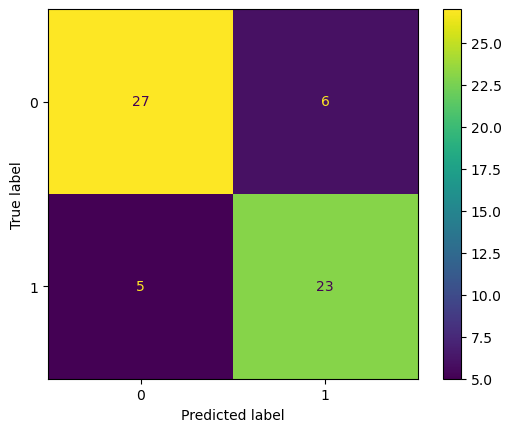

In [11]:
ConfusionMatrixDisplay.from_estimator(
    log_model,
    X_test_scaled,
    y_test
)

plt.show()

In [12]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.9393939393939394


In [13]:
from sklearn.tree import DecisionTreeClassifier

In [14]:
dt_model = DecisionTreeClassifier(random_state=42)

In [15]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [16]:
dt_pred = dt_model.predict(X_test)

In [17]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

Accuracy: 0.8032786885245902


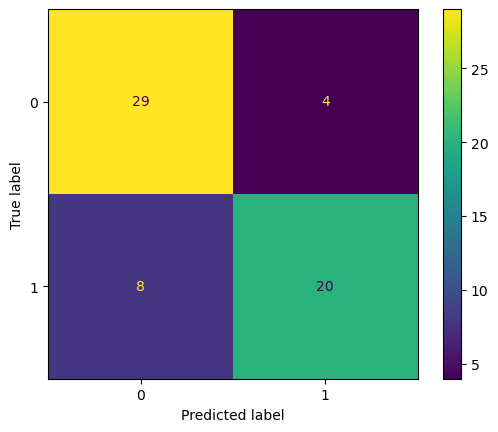

In [18]:
ConfusionMatrixDisplay.from_estimator(
    dt_model,
    X_test,
    y_test
)

plt.show()

In [19]:
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, dt_prob))

ROC-AUC: 0.7965367965367965


In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [22]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [23]:
rf_pred = rf_model.predict(X_test)

In [24]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

Accuracy: 0.8688524590163934


In [25]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



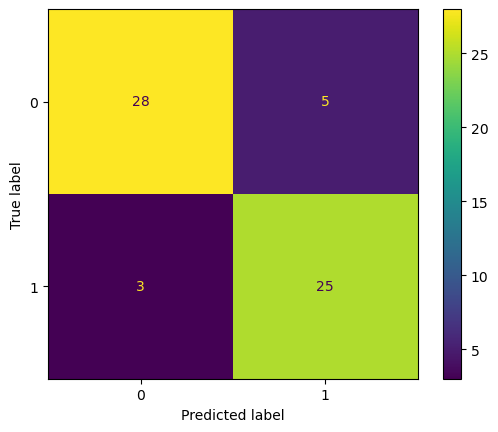

In [26]:
ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.show()

In [27]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

ROC-AUC: 0.9518398268398268


In [28]:
joblib.dump(rf_model, "../artifacts/random_forest.pkl")

['../artifacts/random_forest.pkl']

In [29]:
import joblib

joblib.dump(rf_model, "../artifacts/best_model.pkl")

['../artifacts/best_model.pkl']

In [30]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

comparison = comparison.sort_values(by="ROC-AUC", ascending=False)

comparison

,Model,Accuracy,ROC-AUC
2,Random Forest,0.868852,0.951840
0,Logistic Regression,0.819672,0.939394
1,Decision Tree,0.803279,0.796537


## Model Comparison

Three machine learning models were trained and evaluated:

- Logistic Regression
- Decision Tree
- Random Forest

Among these, Random Forest achieved the highest ROC-AUC score and the best overall predictive performance.

Therefore, Random Forest was selected as the final model and saved as `best_model.pkl` for deployment.

In [32]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,thal_7.0,0.128957
5,thalach,0.125898
8,ca,0.109897
11,cp_4.0,0.099668
7,oldpeak,0.095247
0,age,0.085385
2,trestbps,0.081874
3,chol,0.081720
6,exang,0.046124
1,sex,0.039217


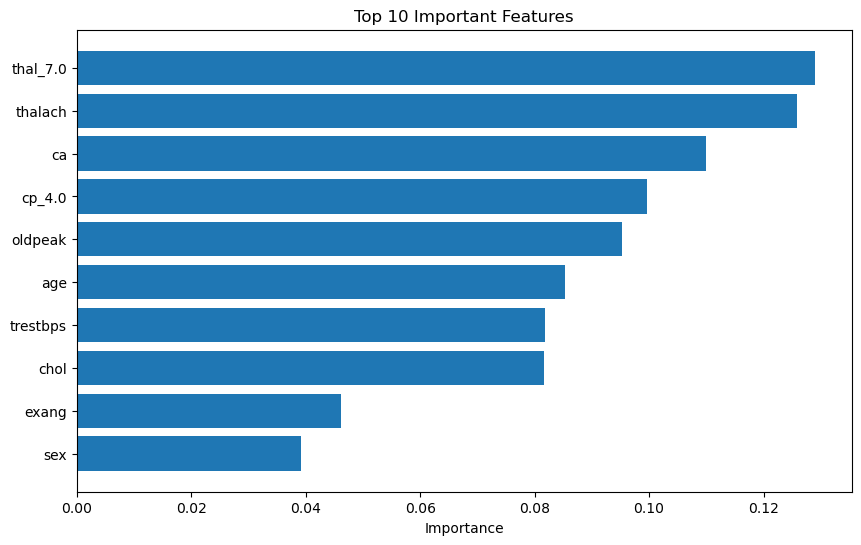

In [33]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

plt.gca().invert_yaxis()

plt.show()

## Observation

The Random Forest model identifies the most influential features for predicting heart disease.

Features such as chest pain type, maximum heart rate, oldpeak, and the number of major vessels contribute significantly to prediction.

Understanding feature importance improves model interpretability and provides insights into which clinical attributes influence predictions the most.

In [35]:
from sklearn.metrics import RocCurveDisplay

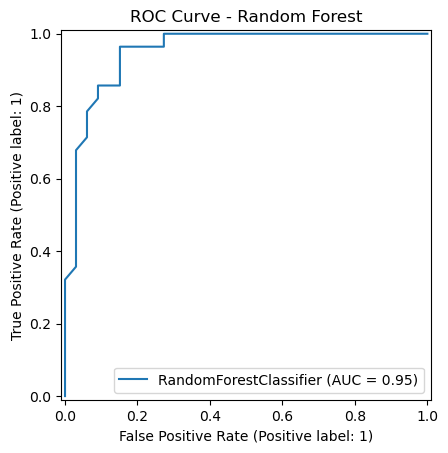

In [36]:
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")

plt.show()

## Observation

The ROC curve illustrates the trade-off between the True Positive Rate and False Positive Rate across different classification thresholds.

The Random Forest model achieves a high ROC-AUC score, indicating strong ability to distinguish between patients with and without heart disease.

In [38]:
from sklearn.model_selection import cross_val_score

In [39]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

In [40]:
print("Cross Validation Scores:")

print(cv_scores)

print()

print("Average Accuracy:", cv_scores.mean())

Cross Validation Scores:
[0.80327869 0.86885246 0.81967213 0.78333333 0.76666667]

Average Accuracy: 0.8083606557377049


In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

In [43]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

In [44]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 5, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='roc_auc')

In [45]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [46]:
print("Best ROC-AUC:", grid_search.best_score_)

Best ROC-AUC: 0.8998316498316499


In [47]:
best_rf = grid_search.best_estimator_

In [48]:
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred_best))

Accuracy: 0.9016393442622951


In [50]:
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))

ROC-AUC: 0.9588744588744589


In [51]:
print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.94      0.88      0.91        33
           1       0.87      0.93      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61



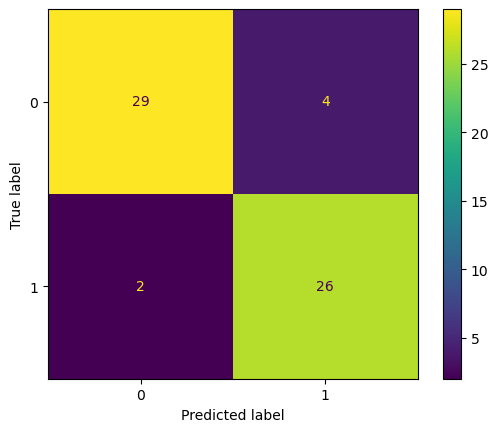

In [52]:
ConfusionMatrixDisplay.from_estimator(
    best_rf,
    X_test,
    y_test
)

plt.show()

In [53]:
import joblib

# Save the feature names used to train the model
joblib.dump(X_train.columns.tolist(), "../artifacts/feature_names.pkl")

print("Feature names saved successfully!")
print(X_train.columns.tolist())

Feature names saved successfully!
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'restecg_1.0', 'restecg_2.0', 'slope_2.0', 'slope_3.0', 'thal_6.0', 'thal_7.0']


In [54]:
import os
import joblib
from sklearn.pipeline import Pipeline

# Path to artifacts folder
artifacts_dir = "../artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

# Create inference pipeline
heart_pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_rf)
])

# Save pipeline
pipeline_path = os.path.join(artifacts_dir, "heart_pipeline.pkl")
joblib.dump(heart_pipeline, pipeline_path)

print("=" * 50)
print("Heart pipeline saved successfully!")
print("Location:", pipeline_path)
print("=" * 50)

Heart pipeline saved successfully!
Location: ../artifacts\heart_pipeline.pkl


In [55]:
import os
import joblib

artifacts_dir = "../artifacts"
os.makedirs(artifacts_dir, exist_ok=True)

joblib.dump(scaler, os.path.join(artifacts_dir, "scaler.pkl"))

print("Scaler saved successfully!")

Scaler saved successfully!


In [56]:
import os

print(os.path.abspath("../artifacts/scaler.pkl"))
print(os.path.exists("../artifacts/scaler.pkl"))

C:\Users\Akshay Gund\Projects\heart-disease-mlops\artifacts\scaler.pkl
True
